In [1]:
NZ=2396; NX=13601; H=1.25

velmin=1065
velmax=4700

#chosen
fpeak=4

#consequently
h=int(velmin/fpeak/2.5/5)
nz=int(NZ*H/h)+1
nx=int(NX*H/h)+1

print('h,nz,nx=',h,nz,nx)

dt=0.6*h/velmax *0.98
T=5 #time window [s]
nt=int(T/dt)
print('dt,nt=',dt,nt)

dt=0.0026
nt=int(T/dt)
print('adjusted dt,nt=',dt,nt)

ntr=670

h,nz,nx= 21 143 810
dt,nt= 0.0026272340425531914 1903
adjusted dt,nt= 0.0026 1923


In [2]:
import os
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def write(filename,data,n=(nx,nz)):
    data.T.astype('float32').tofile(filename)

    
def hilb(data,axis=0):
    return np.imag(hilbert(data,axis=axis))

    
def imshow(data,perc=None,clip=None,clipmin=None,
        #    cmap='viridis',
            cmap='jet',
           title=None,grid=True, label=None, colorbar_title=None):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    im=plt.imshow(data,vmin=clipp[0],vmax=clipp[1],cmap=cmap,aspect='auto',extent=[0,(nx-1)*h/1000 , (nz-1)*h/1000, 0 ])
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    #plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    if label!=None:plt.xlabel(label[0]); plt.ylabel(label[1])
    if title!=None: plt.title(title)
    if colorbar_title!=None:
        cbar = plt.colorbar(im);cbar.ax.set_title(colorbar_title)

def imshow_shot(data,perc=None,clip=None,clipmin=None,cmap='gray',colorbar=None,title=None,grid=True, label=None):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],cmap=cmap,aspect='auto',extent=[0,(nx-1)*h/1000 , (nt-1)*dt, 0 ])
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    if colorbar!=None: plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    if label!=None: plt.xlabel(label[0]); plt.ylabel(label[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > $out
        
def run_remote(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        #!./run.sh
        print("bash ./run.sh")
    else:
        #!./run.sh > $out
        print(f"bash ./run.sh > {out}")

## Prepare

In [10]:
##code
#!(cd ../../ ; git pull ; git checkout teaching ; make prepare)
#!(cd ../../FWD ; make cleanall ; make)
#!(cd ../../FWI ; make cleanall ; make)
#!gfortran smoothgauss2dfast_zhou.f90 -o smoothgauss2dfast_zhou

In [4]:
# #clone model
# # !wget https://s3.amazonaws.com/open.source.geoscience/open_data/elastic-marmousi/elastic-marmousi-model.tar.gz #https://wiki.seg.org/wiki/AGL_Elastic_Marmousi
# # !tar -xvzf elastic-marmousi-model.tar.gz
# # !(cd ./elastic-marmousi-model/model/ ; for fi in `ls *.tar.gz`; do tar -xvzf $$fi; done)
# !segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_P-WAVE_VELOCITY_1.25m.segy | sugain bias=0 | sustrip > vp.bin
# !segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_DENSITY_1.25m.segy | sustrip | farith op=scale scale=1000 > rho.bin  #convert to [kg/m3]

# !unif2 ninf=1 nz=281 nx=1361 v00=2000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=4000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=1 > rho.bin

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00144723 s, 2.2 MB/s
n1=2801 n2=13601 d1=0.001250
nt=2801 ntr=13601 dt=0.001250
ns=2801
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00190142 s, 1.7 MB/s
n1=2801 n2=13601 d1=0.001250
nt=2801 ntr=13601 dt=0.001250
ns=2801


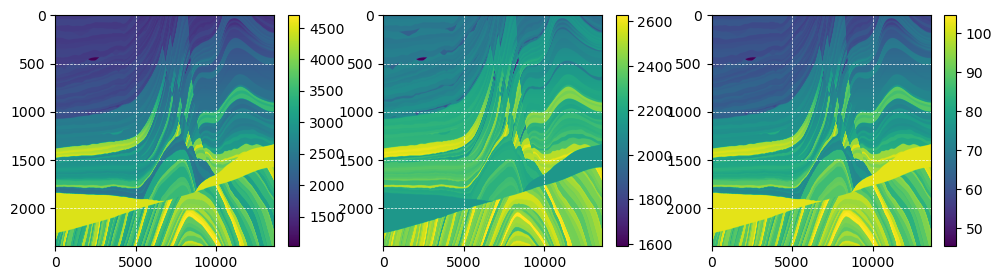

In [11]:
#chop the water layer
vp = read('../11_Marmousi-runFWI/vp.bin',(13601,2801)) [405:,:]
rho= read('../11_Marmousi-runFWI/rho.bin',(13601,2801))[405:,:]

#make Qp model by empirical law
qp = vp**0.5 #leads to a range of ~35--65, small enough to cause instability
# qp = vp**0.75 #leads to a range of ~200--550, not yet instability
# qp = vp**0.6 #65-160
qp = vp**0.55 #40-110

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(vp)
plt.subplot(1,3,2); imshow(rho)
plt.subplot(1,3,3); imshow(qp)

In [22]:
print(vp.shape)
print(qp.min())
print(qp.max())

(2396, 13601)
45.35198
104.62943


In [23]:
#save to disk
write('vpt.bin',vp)
write('rhot.bin',rho)
write('qpt.bin',qp)

In [24]:
#downsample true models
!make -B true

#make init models
!make -B init

#catenate
str=f'cat vpt.{h}m   rhot.{h}m   qpt.{h}m  > true'
!$str
!cat vpt.init  rhot.init  qpt.init > init

echo 20.1680
20.1680
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.48/sig will be suppressed
 c'est à dire que les nombres d'onde qui sont plus large que 0.48/sig ont l'amplitude sous 1% du crête. 
 Smooth parameter (0) or its inverse (1) or its inverse square (2)
 Constant topography (>=0) or variant (<0)
  go to the square inverse
  grids points involved il2 il1 =           65          65
  go back from the square inverse
   9.28382976E+10
unisam2 < vpt.smth > vpt.21m \
  nx1=2396  dx1=1.25    nx2=13601  dx2=1.25 \
  n1=143    d1=21      n2=810   d2=21
echo 20.1680
20.1680
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.

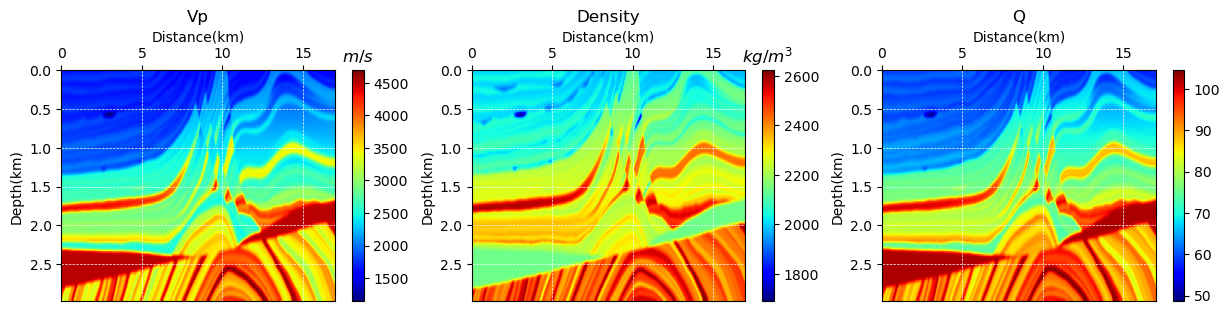

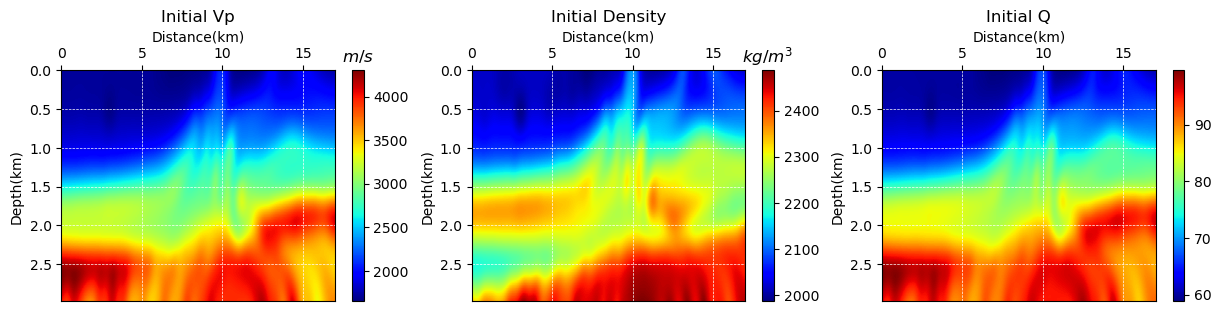

In [25]:

#plot

plt.figure(figsize=(15,3))

true=read('true',(3*nx,nz))
plt.subplot(1,3,1); imshow(true[:,:nx],title='Vp',colorbar_title=r'$m/s$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,2); imshow(true[:,nx:2*nx],title='Density',colorbar_title=r'$kg/m^3$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,3); imshow(true[:,2*nx:],title='Q',colorbar_title=' ',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.savefig('./figures/True models.svg',bbox_inches='tight',transparent=True)

plt.figure(figsize=(15,3))
init=read('init',(3*nx,nz))
plt.subplot(1,3,1); imshow(init[:,:nx],title='Initial Vp',colorbar_title=r'$m/s$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,2); imshow(init[:,nx:2*nx],title='Initial Density',colorbar_title=r'$kg/m^3$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,3); imshow(init[:,2*nx:],title='Initial Q',colorbar_title=' ',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.savefig('./figures/Initial models.svg',bbox_inches='tight',transparent=True)

In [ ]:
#min max of true vp
print(true[:,:nx].min(),true[:,:nx].max())
print(init[:,2*nx:].min())

1142.8925 4691.6123
58.811752


(143, 2430)

In [8]:
!cat setup_default

MODEL_SIZE              '143 810  1'
MODEL_SPACING           '21  21   1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho qp'
MODEL_ATTRIBUTES_WRITE   vp
#FILE_TOPO              'topo'

IS_FREESURFACE          F
FREE_SURFACE_PPG        T
IS_Q_ATTENUATION        T
IF_HICKS                T
IF_BLOOM                T

ACQUI_GEOMETRY          spread
FS                      '  21   1200  0'
#DS			'  0   100   0'
#NS			 144
DS			'  0   400  0'
NS			 36
FR                      '  21   0   0'
DR                      '  0   25  0'
NR                       670

SCOMP                   dpdz  #p
RCOMP                   dpdz  #p
IF_MUST_USE_RCOMP       T

WAVELET_TYPE	ricker

FPEAK        4
NT           1923
DT           0.0026

#SNAPSHOT      p
#NSNAPSHOT    50

#############
## for FWI ##
#############
FILE_DATA_PREFIX    './results_obs/Ru_Shot'
WEIGHTING           'none'

UPDATE_WAVELET	no

PARAMETER           'vp:1065:4700'

SMOOTHING     'none'
#PRECO         'z^0'

JOB         

In [27]:
!cat setup_default

MODEL_SIZE              '143 810  1'
MODEL_SPACING           '21  21   1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho qp'
MODEL_ATTRIBUTES_WRITE   vp
#FILE_TOPO              'topo'

IS_FREESURFACE          F
FREE_SURFACE_PPG        T
IS_Q_ATTENUATION        T
IF_HICKS                T
IF_BLOOM                T

ACQUI_GEOMETRY          spread
FS                      '  21   1200  0'
#DS			'  0   100   0'
#NS			 144
DS			'  0   400  0'
NS			 36
FR                      '  21   0   0'
DR                      '  0   25  0'
NR                       670

SCOMP                   dpdz  #p
RCOMP                   dpdz  #p
IF_MUST_USE_RCOMP       T

WAVELET_TYPE	ricker

FPEAK        4
NT           1923
DT           0.0026

#SNAPSHOT      p
#NSNAPSHOT    50

#############
## for FWI ##
#############
FILE_DATA_PREFIX    './results_obs/Ru_Shot'
WEIGHTING           'none'

UPDATE_WAVELET	no

PARAMETER           'vp:1065:4700 qp:50:110'

SMOOTHING     'none'
#PRECO         'z^0'

JO

## Observed data

In [70]:
!cp setup_default setup
# !rm -r ./
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
# !echo "FREE_SURFACE_PPG      T"  >> setup
# !echo "IF_HICKS         F" >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Feb 23 17:11 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/23/2026
System time: 17:13:13
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL

In [81]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
!echo "NS               1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
# !echo "FREE_SURFACE_PPG      T"  >> setup
# !echo "IS_FREESURFACE          F"  >> setup
!echo "IS_Q_ATTENUATION   T" >> setup
!echo "SNAPSHOT         p" >> setup
# !echo "IF_HICKS         F" >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Feb 23 17:20 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/23/2026
System time: 17:20:22
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coe

/tmp/ipykernel_4783/3847517790.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,3,1); imshow_shot(read_su('results_obs_noQ/Ru_Shot0001.su'),clip=[-0.01,0.01],title='Acoustic',label=['Distance(km)','Time(s)'])


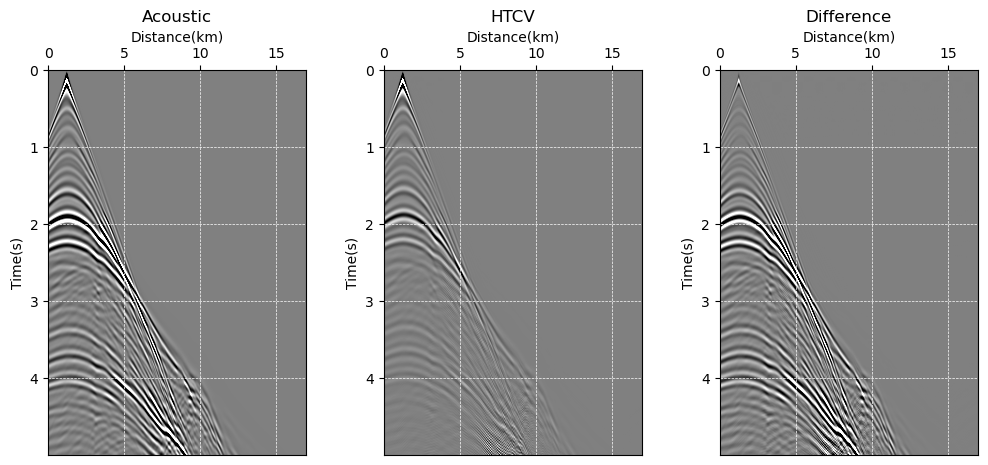

In [82]:
fig,ax=plt.subplots(figsize=(12,5))
plt.subplot(1,3,1); imshow_shot(read_su('results_obs_noQ/Ru_Shot0001.su'),clip=[-0.01,0.01],title='Acoustic',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,2); imshow_shot(read_su('results_obs/Ru_Shot0001.su'    ),clip=[-0.01,0.01],title='HTCV',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,3); imshow_shot(read_su('results_obs_noQ/Ru_Shot0001.su')-read_su('results_obs/Ru_Shot0001.su'),clip=[-0.01,0.01],title='Difference',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplots_adjust(wspace=0.3)
# plt.savefig('./figures/results_with_Q.svg',bbox_inches='tight',transparent=True)

In [47]:
a=read_su('results_obs_noQ/Ru_Shot0001.su')
a.shape

(1923, 670)

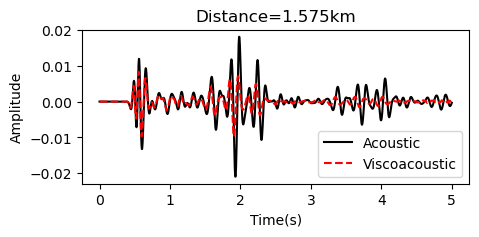

In [3]:
t=np.linspace(0,dt*nt,nt)
plt.figure(figsize=(5,2))
plt.plot(t,read_su('results_obs_noQ/Ru_Shot0001.su')[:,75],color='k')
plt.plot(t,read_su('results_obs/Ru_Shot0001.su'    )[:,75],'--r')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude')
plt.title(f'Distance={75*h/1000}km')
plt.legend(['Acoustic', 'Viscoacoustic'])
plt.savefig('./figures/1shot_compare.png',bbox_inches='tight',transparent=True)

## FWI gradient

In [4]:
!cp setup_default setup
!rm -r ./results_grad_noQ
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "SNAPSHOT      p"  >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Feb 23 17:20 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/23/2026
System time: 17:26:39
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) metho

In [5]:
!cp setup_default setup
!rm -r ./results_grad
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
!echo "SNAPSHOT      p"  >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Feb 23 17:20 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/23/2026
System time: 17:26:57
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartes

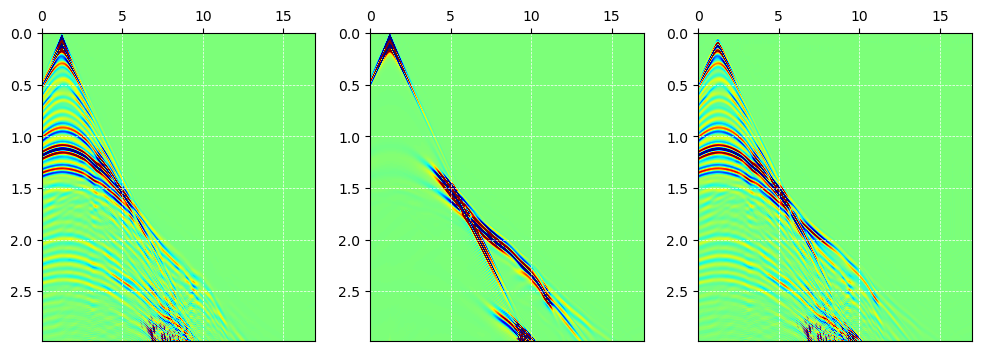

In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su' ),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_grad/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_grad/dadj_Shot0001.su'),perc=98)

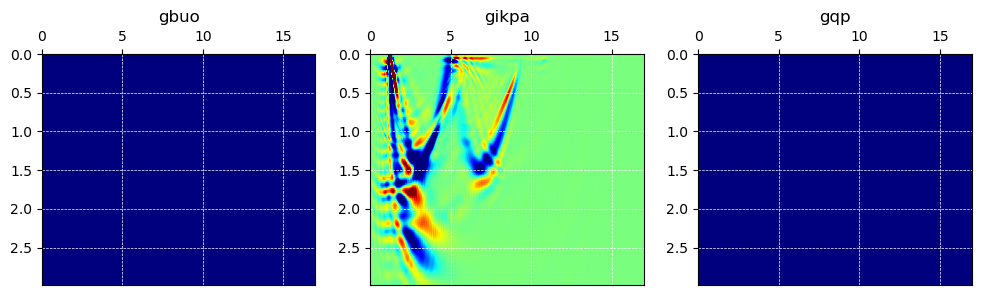

In [7]:
grad=read('results_grad_noQ/correlate_gradient',n=(3*nx,nz))
          
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad[:,:nx],    perc=98,title='gbuo')
plt.subplot(1,3,2); imshow(grad[:,nx:2*nx],perc=98,title='gikpa')
plt.subplot(1,3,3); imshow(grad[:,2*nx:],  perc=98,title='gqp')

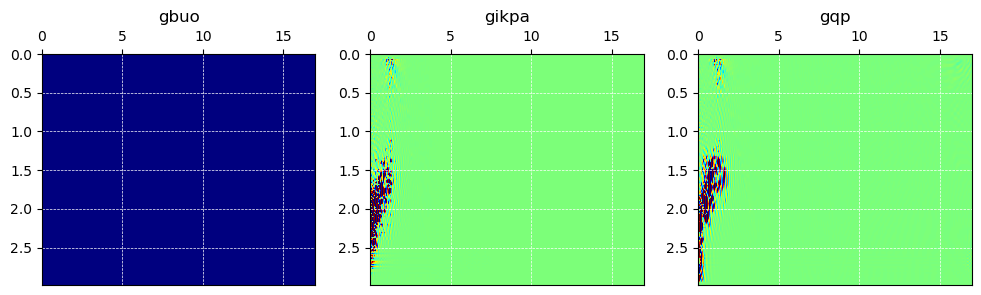

In [12]:
grad=read('results_grad/correlate_gradient',n=(3*nx,nz))
          
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad[:,:nx],    perc=98,title='gbuo')
plt.subplot(1,3,2); imshow(grad[:,nx:2*nx],perc=98,title='gikpa')
plt.subplot(1,3,3); imshow(grad[:,2*nx:],  perc=98,title='gqp')

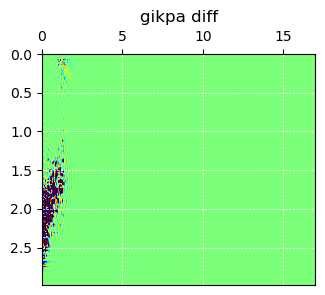

In [9]:

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results_grad_noQ/correlate_gradient',n=(3*nx,nz))[:,nx:2*nx]
                          -read('results_grad/correlate_gradient',n=(3*nx,nz))[:,nx:2*nx],
                           perc=98,title='gikpa diff')

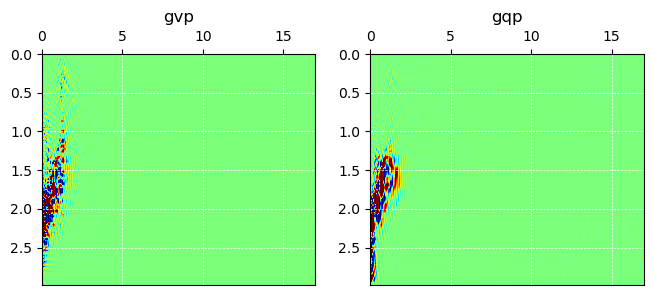

In [10]:
grad=read('results_grad/qp0%pg',n=(2*nx,nz))
          
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad[:,:nx],    perc=98,title='gvp')
plt.subplot(1,3,2); imshow(grad[:,nx:2*nx],perc=98,title='gqp')

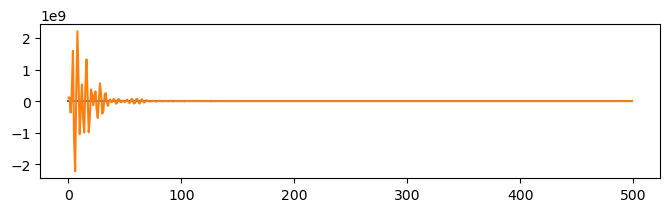

In [11]:
plt.figure(figsize=(8,2))
plt.plot(read('results_grad_noQ/qp0%pg',n=(2*nx,nz))[100,:500],label='no Q')
plt.plot(read('results_grad/qp0%pg',    n=(2*nx,nz))[100,:500],label='with Q')

In [ ]:
def read3d(filename):
    return np.fromfile(filename,dtype='float32')

: 

# **Free Surface**

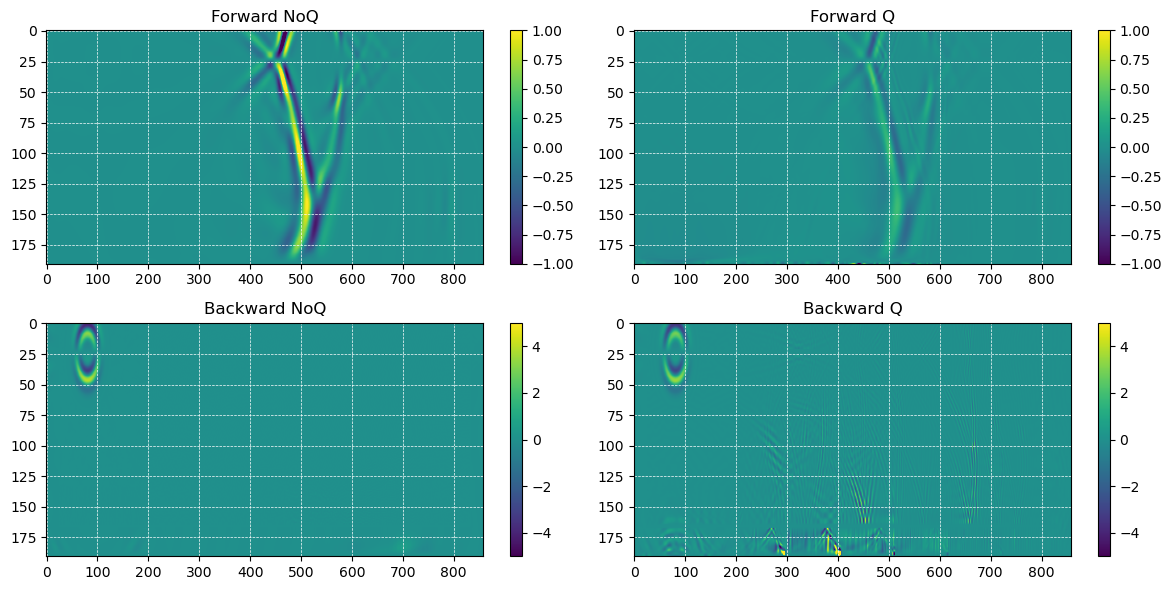

: 

In [ ]:
forward_noQ = read3d('./results_grad_noQ/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T
forward_Q = read3d('./results_grad/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T

rev_noQ = read3d('./results_grad_noQ/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T
rev_Q = read3d('./results_grad/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T

clip1=1
clip2=5
plt.figure(figsize=(12,6))
plt.subplot(2,2,1); imshow(forward_noQ[:,:,50],clip=[-clip1,clip1],title='Forward NoQ')
plt.subplot(2,2,2); imshow(forward_Q[:,:,50],clip=[-clip1,clip1],title='Forward Q')
plt.subplot(2,2,3); imshow(rev_noQ[:,:,45],clip=[-clip2,clip2],title='Backward NoQ')
plt.subplot(2,2,4); imshow(rev_Q[:,:,45],clip=[-clip2,clip2],title='Backward Q')
plt.tight_layout()

# **No Freesurface**

In [ ]:

# forward_noQ_noFS = read3d('./results_grad_noQ_noFS/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T
# forward_Q_noFS = read3d('./results_grad_noFS/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T

# rev_noQ_noFS = read3d('./results_grad_noQ_noFS/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T
# rev_Q_noFS = read3d('./results_grad_noFS/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T

# plt.figure(figsize=(12,6))
# plt.subplot(2,2,1); imshow(forward_noQ_noFS[:,:,45],clip=[-clip1,clip1],title='Forward NoQ')
# plt.subplot(2,2,2); imshow(forward_Q_noFS[:,:,45],clip=[-clip1,clip1],title='Forward Q')
# plt.subplot(2,2,3); imshow(rev_noQ_noFS[:,:,45],clip=[-clip2,clip2],title='Backward NoQ')
# plt.subplot(2,2,4); imshow(rev_Q_noFS[:,:,45],clip=[-clip2,clip2],title='Backward Q')
# plt.tight_layout()

: 

: 

## Multiple shots

### data

In [ ]:
!cp setup_default setup
!rm -r results_obs_noQ/
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
# run_remote(np=36,nthreads=1,out='out')
run(np=36,nthreads=1,out='out')

: 

In [ ]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Jan 21 11:01 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 01/21/2026
System time: 11:02:11
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL

: 

In [ ]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
# run_remote(np=36,nthreads=1,out='out')
run(np=36,nthreads=1,out='out')

: 

In [ ]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Jan 21 11:01 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 01/21/2026
System time: 11:03:00
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coe

: 

### gradient

In [ ]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "LAP_FRAC       '0.1 0.2 0.2' "  >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')
#~3min for one gradient

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point excep

: 

In [ ]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Jan 21 11:01 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 01/21/2026
System time: 11:03:49
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) metho

: 

In [ ]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
!echo "SMOOTHING        Laplacian "  >> setup
!echo "LAP_FRAC       '0.1 0.2 0.2' "  >> setup
!echo "PRECO            z^1.5       "  >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floatin

: 

In [ ]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Jan 21 11:01 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: e9a57c6
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 01/21/2026
System time: 11:06:07
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartes

: 

: 

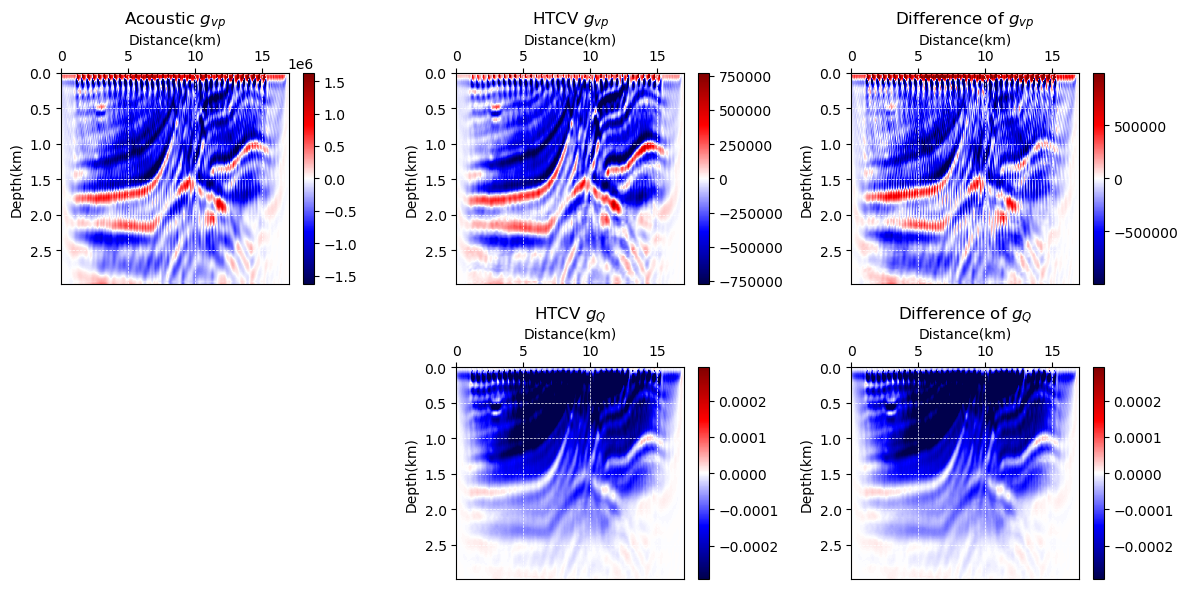

: 

In [ ]:
grad0=read('results_grad_noQ/correlate_gradient',(3*nx,nz)) [:,:]
grad1=read('results_grad/correlate_gradient'    ,(3*nx,nz)) [:,:]

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(grad0[:,nx:2*nx],perc=98,cmap='seismic',title=r'Acoustic $g_{vp}$',label=['Distance(km)','Depth(km)'],colorbar_title=''); ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,2); imshow(grad1[:,nx:2*nx],perc=98,cmap='seismic',title=r'HTCV $g_{vp}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,3); imshow(grad0[:,nx:2*nx]-grad1[:,nx:2*nx],perc=98,cmap='seismic',title=r'Difference of $g_{vp}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.subplot(2,3,4); imshow(grad0[:,2*nx:],perc=90,cmap='seismic',title=r'Acoustic $g_{Q}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,5); imshow(grad1[:,2*nx:],perc=90,cmap='seismic',title=r'HTCV $g_{Q}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,6); imshow(grad1[:,2*nx:]-grad0[:,2*nx:],perc=90,cmap='seismic',title=r'Difference of $g_{Q}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.tight_layout()
plt.savefig('./figures/Gradients comparison.svg',bbox_inches='tight',transparent=True)


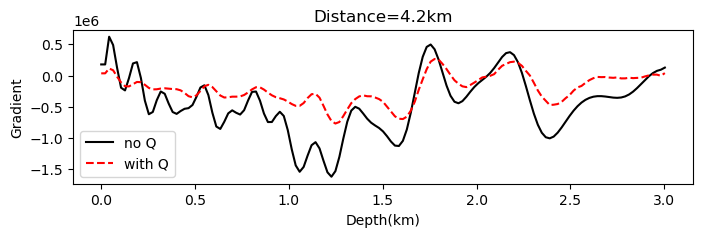

: 

In [ ]:
depth=np.linspace(0,h*nz,nz)/1000
plt.figure(figsize=(8,2))
plt.plot(depth,grad0[:,nx+200],color='k',label='Acoustic')
plt.plot(depth,grad1[:,nx+200],'--r',label='Viscoacoustic')
plt.legend(['no Q', 'with Q'])
plt.xlabel('Depth(km)')
plt.ylabel('Gradient')
plt.title(f'Distance={200*h/1000}km')
plt.savefig('./figures/gradient_1shot_comparison.png',bbox_inches='tight',transparent=True)

: 

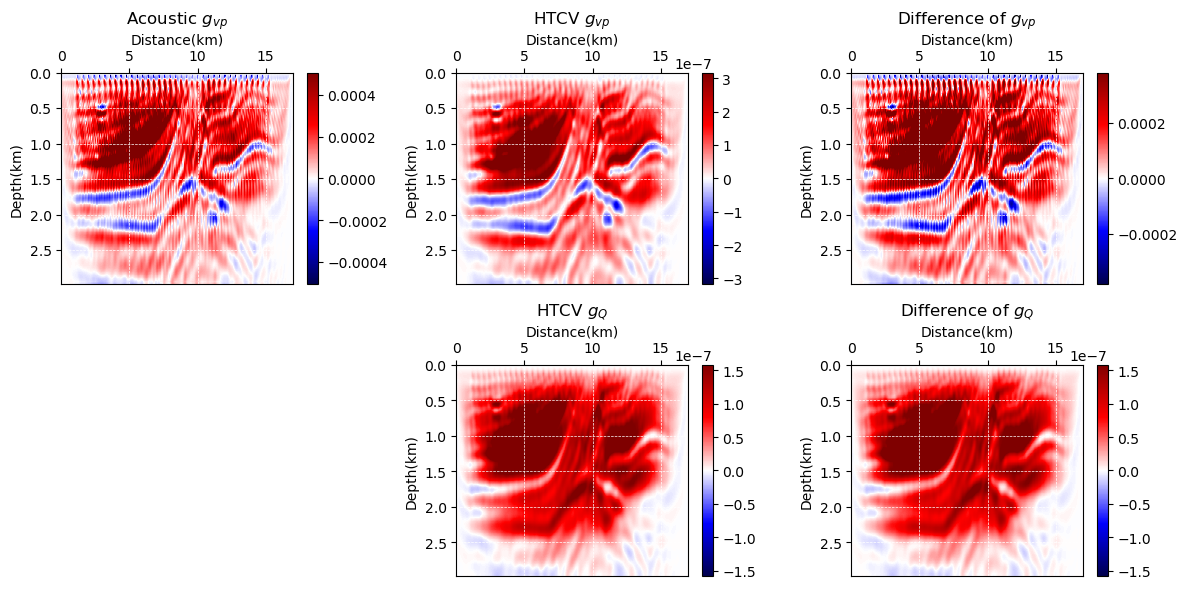

: 

In [ ]:
gradqp1=read('results_grad_noQ/qp0%pg',(2*nx,nz))
gradqp2=read('results_grad/qp0%pg',(2*nx,nz))

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(gradqp1[:,:nx],perc=95,title=r'Acoustic $g_{vp}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,2); imshow(gradqp2[:,:nx],perc=95,title=r'HTCV $g_{vp}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,3); imshow(gradqp1[:,:nx]-gradqp2[:,:nx],perc=90,title=r'Difference of $g_{vp}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.subplot(2,3,4); imshow(gradqp1[:,nx:],perc=90,title=r'Acoustic $g_{Q}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,5); imshow(gradqp2[:,nx:],perc=90,title=r'HTCV $g_{Q}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,6); imshow(gradqp2[:,nx:]-gradqp1[:,nx:],perc=90,title=r'Difference of $g_{Q}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.tight_layout()
plt.savefig('./figures/Precondation Gradient comparison.svg',bbox_inches='tight',transparent=True)

0.09999999999999999

: 

## FWI NOsmth NOzpow

In [ ]:
# !cp setup_default setup
# !echo "FILE_MODEL       init" >> setup
# !echo "DIR_OUT          res_NOsmth_NOzpow " >> setup
# !echo "PRECO            none         "  >> setup
# !echo "JOB              optimization " >> setup
# # run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
# run(app='../../exe/FWI',np=36,nthreads=1,out='out')

: 

In [ ]:
# plt.figure(figsize=(12,3))
# imshow(read('res_NOsmth_NOzpow/qp0%pg'),perc=98)

: 

In [ ]:
# !cat res_NOsmth_NOzpow/optimization.log

: 

: 

In [ ]:
# plt.figure(figsize=(12,3))
# plt.subplot(1,3,1); imshow(read('res_NOsmth_NOzpow/model_Iter1'))
# plt.subplot(1,3,2); imshow(read('res_NOsmth_NOzpow/model_Iter5'))
# plt.subplot(1,3,3); imshow(read('res_NOsmth_NOzpow/model_Iter9'))

: 

: 

## FWI smthx0.2 zpow1

In [ ]:
!cp setup_default setup
!rm -r ./res_smthx0.2_zpow1
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_smthx0.2_zpow1 " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.2 0.2 0.2' "  >> setup
!echo "PRECO            z^1         "  >> setup
!echo "JOB              optimization " >> setup
!echo "SNAPSHOT      p"  >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

mv: cannot stat 'res_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_

: 

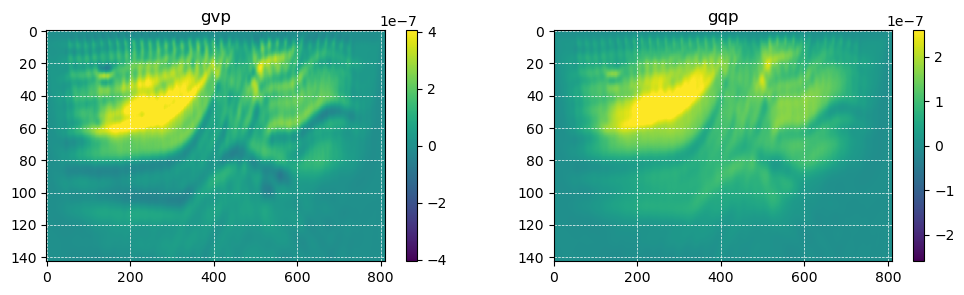

: 

In [ ]:
plt.figure(figsize=(12,3))
grad_qp=read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz))
plt.subplot(1,2,1); imshow(grad_qp[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(grad_qp[:,nx:],perc=98,title='gqp')
# imshow(read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz)),perc=98)

In [ ]:
!cat res_smthx0.2_zpow1/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =   40
     Max linesearches allowed =   12
     Max gradients allowed    =   70
     Linesearch scaler        =3.27188574E+03
     Initial gradient L1norm (║g0║₁)  =5.5834E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 1.0459E+01 100.000  100.000     -2.88E-02
            1      2  1.00E+00       1.0145E+01                      -2.90E-02   T F
            2      3  1.00E+01       7.3678E+00                      -2.17E-02   T T
     1             3                 7.3678E+00  70.442   78.972     -1.08E+00
 -------

: 

: 

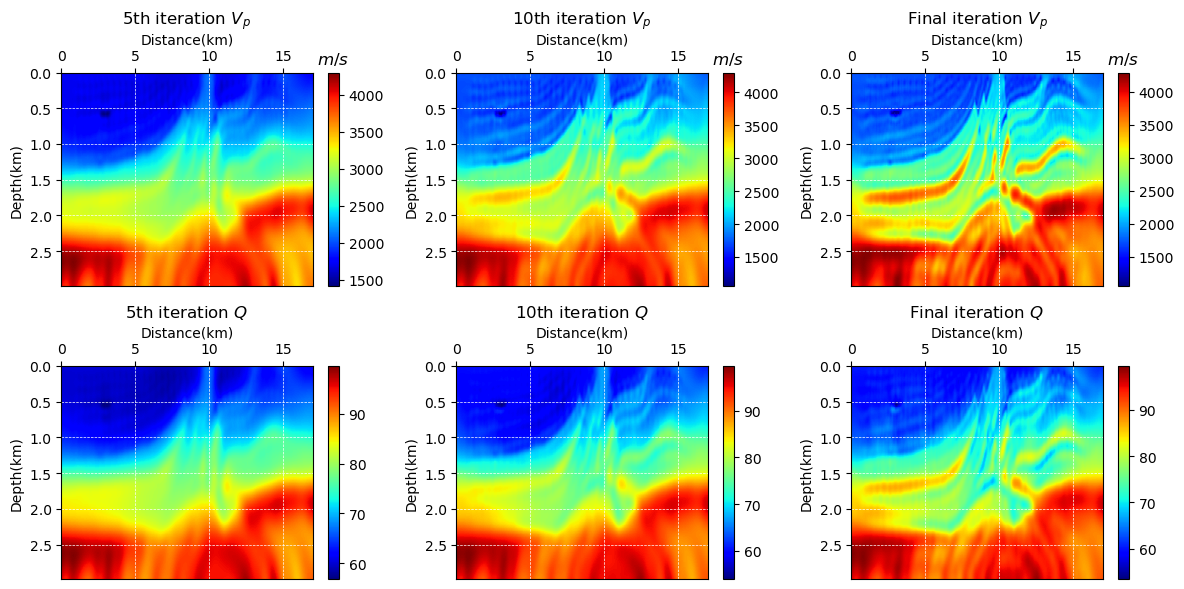

: 

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(read('res_smthx0.2_zpow1/model_Iter5',n=(2*nx,nz))[:,:nx],title=r'5th iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,2); imshow(read('res_smthx0.2_zpow1/model_Iter10',n=(2*nx,nz))[:,:nx],title=r'10th iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,3); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],title=r'Final iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,4); imshow(read('res_smthx0.2_zpow1/model_Iter5',n=(2*nx,nz))[:,nx:],title=r'5th iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.subplot(2,3,5); imshow(read('res_smthx0.2_zpow1/model_Iter10',n=(2*nx,nz))[:,nx:],title=r'10th iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.subplot(2,3,6); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:],title=r'Final iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.tight_layout()
plt.savefig('./figures/Inversion results.svg',bbox_inches='tight',transparent=True)


# plt.figure(figsize=(12,3))
# plt.subplot(1,3,1); imshow(read('res_smthx0.2_zpow1/model_final'))
# plt.subplot(1,3,2); imshow(read('res_smthx0.2_zpow1/model_final'))

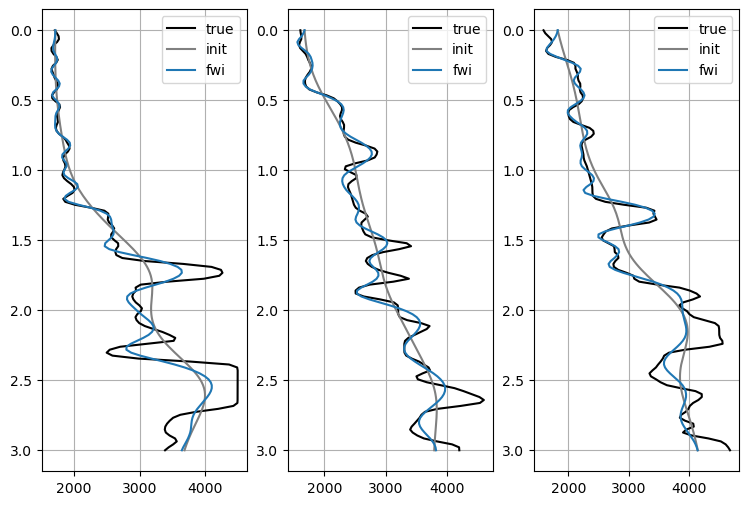

: 

In [ ]:
iz=depth

# fwi1=read('res_smthx0.2_zpow1/model_final')
fwi1_vp=read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]
fwi1_qp=read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:]


plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()


In [ ]:
true.shape

(143, 2430)

: 

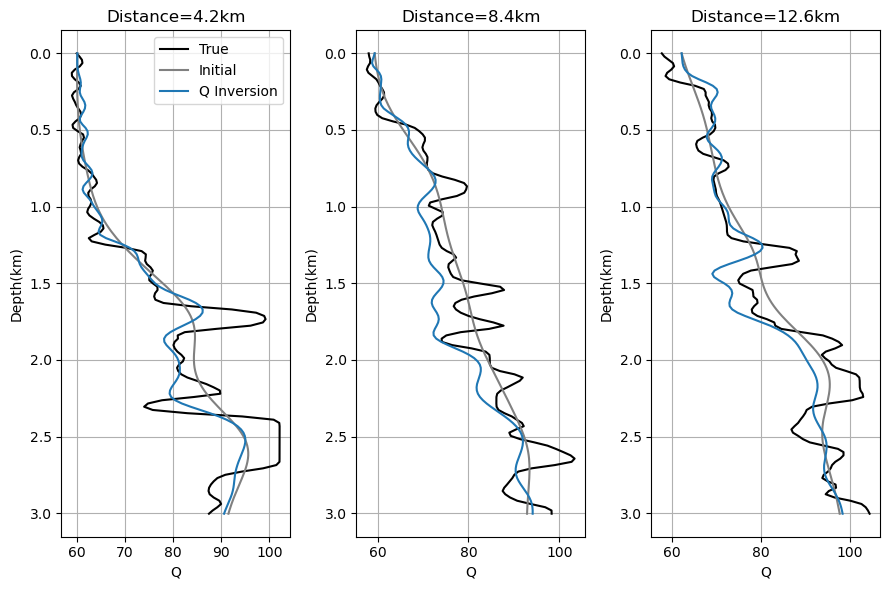

: 

In [ ]:
plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,2*nx+ix],iz,label='True',color='k')
plt.plot(init[:,2*nx+ix],iz,label='Initial',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='Q Inversion')
plt.gca().invert_yaxis()
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,2*nx+ix],iz,label='True',color='k')
plt.plot(init[:,2*nx+ix],iz,label='Init',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
# plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,2*nx+ix],iz,label='true',color='k')
plt.plot(init[:,2*nx+ix],iz,label='init',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='fwi')
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.gca().invert_yaxis()
plt.grid(visible=True)
# plt.legend()
plt.tight_layout()
plt.savefig('./figures/Q trace comparison.svg',bbox_inches='tight',transparent=True)

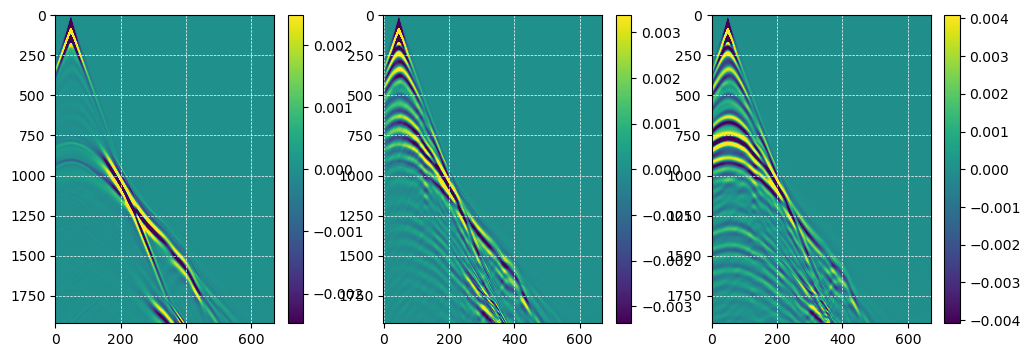

: 

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('res_smthx0.2_zpow1/Ru_Iter1_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('res_smthx0.2_zpow1/Ru_Iter14_Shot0001.su' ),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)

## FWI noQ smthx0.2 zpow1

In [ ]:
!cp setup_default setup
!rm -r ./res_noQ_smthx0.2_zpow1/
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_noQ_smthx0.2_zpow1 " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.2 0.2 0.2' "  >> setup
!echo "PRECO            z^1          "  >> setup
!echo "JOB              optimization " >> setup
!echo "SNAPSHOT      p"  >> setup
!echo "PARAMETER    'vp:1065:4700'"  >> setup

# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

mv: cannot stat 'res_noQ_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0001.su': No such 

: 

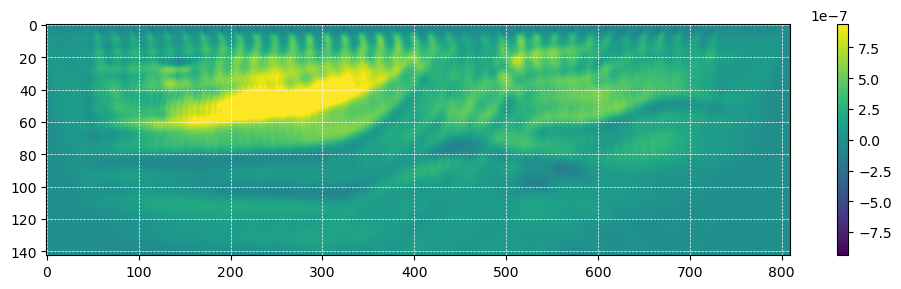

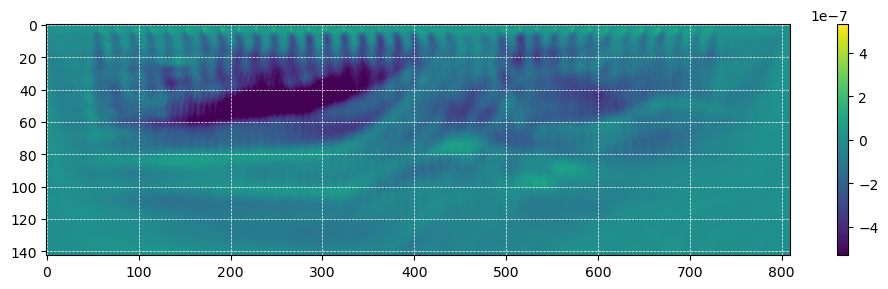

: 

In [ ]:
plt.figure(figsize=(12,3))
imshow(read('res_noQ_smthx0.2_zpow1/qp0%pg'),perc=98)

plt.figure(figsize=(12,3))
imshow(read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz))[:,:nx]-read('res_noQ_smthx0.2_zpow1/qp0%pg'),perc=98)

In [ ]:
!cat res_noQ_smthx0.2_zpow1/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =   40
     Max linesearches allowed =   12
     Max gradients allowed    =   70
     Linesearch scaler        =1.45693469E+03
     Initial gradient L1norm (║g0║₁)  =3.1867E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 8.1749E+00 100.000  100.000     -1.83E-02
            1      2  1.00E+00       7.8591E+00                      -1.81E-02   T F
            2      3  1.00E+01       5.8559E+00                      -7.42E-03   T T
     1             3                 5.8559E+00  71.632   61.382     -1.40E-01
 -------

: 

: 

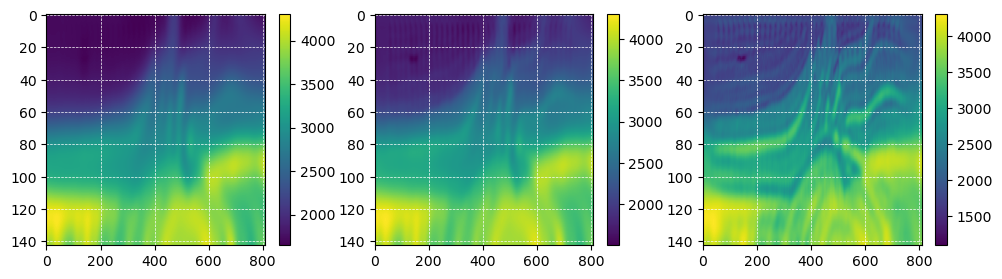

: 

In [ ]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter1',n=(2*nx,nz))[:,:nx])
plt.subplot(1,3,2); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter4',n=(2*nx,nz))[:,:nx])
plt.subplot(1,3,3); imshow(read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx])

# plt.figure(figsize=(12,3))
# plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter30'))
# plt.subplot(1,3,2); imshow(read('res_noQ_smthx0.2_zpow1/model_final'))
# plt.subplot(1,3,3); imshow(read('res_smthx0.2_zpow1/model_final')-read('res_noQ_smthx0.2_zpow1/model_final'))

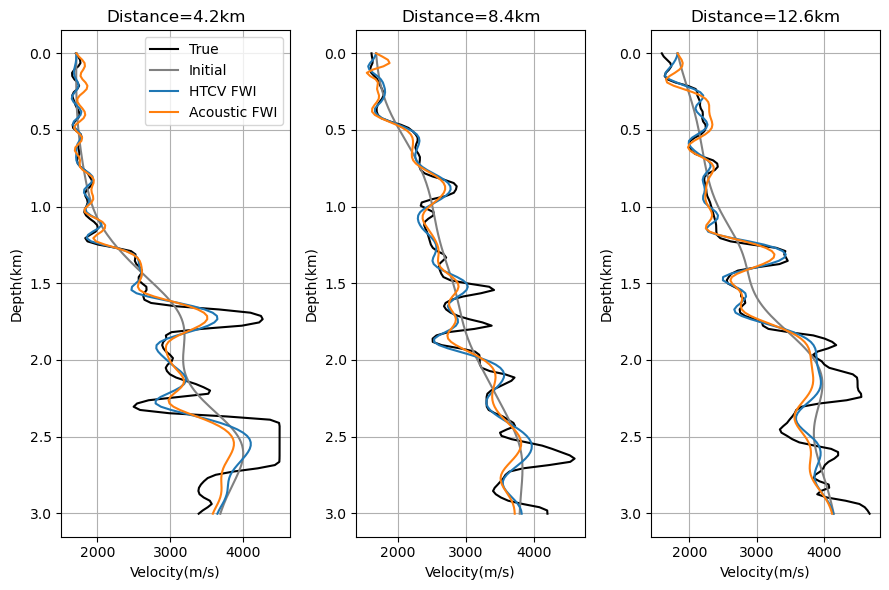

: 

In [ ]:


# fwi1=read(    'res_smthx0.2_zpow1/model_final')
# fwi2=read('res_noQ_smthx0.2_zpow1/model_final')
fwi1=read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]
fwi2=read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]

plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='True',color='k')
plt.plot(init[:,ix],iz,label='Initial',color='gray')
plt.plot(fwi1[:,ix],iz,label='HTCV FWI')
plt.plot(fwi2[:,ix],iz,label='Acoustic FWI')
plt.gca().invert_yaxis()
plt.xlabel('Velocity(m/s)')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='Viscoacoustic FWI')
plt.plot(fwi2[:,ix],iz,label='Acoustic FWI')
plt.gca().invert_yaxis()
plt.xlabel('Velocity(m/s)')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
# plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='Viscoacoustic FWI')
plt.plot(fwi2[:,ix],iz,label='Acoustic FWI')
plt.xlabel('Velocity(m/s)')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.gca().invert_yaxis()
plt.grid(visible=True)
# plt.legend()
plt.tight_layout()
plt.savefig('./figures/Comparison of Acoustic and Viscoacoustic FWI results_traces.svg',bbox_inches='tight',transparent=True)

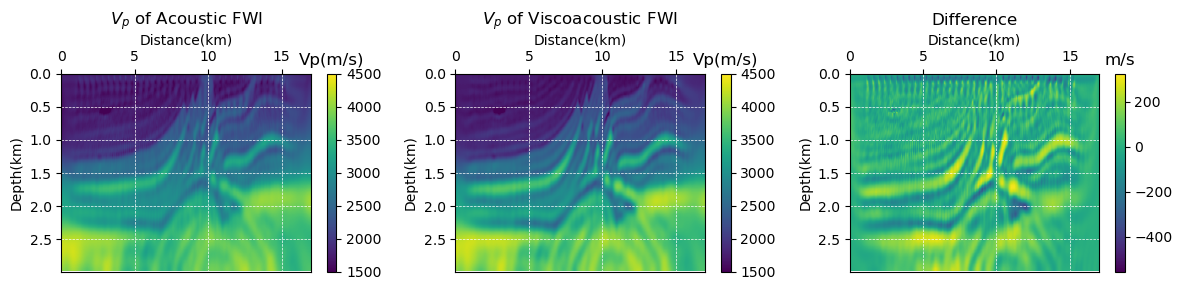

: 

In [ ]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1500,4500],colorbar_title='Vp(m/s)',title=r'$V_p$ of Acoustic FWI',label=['Distance(km)','Depth(km)'])
plt.subplot(1,3,2); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1500,4500],colorbar_title='Vp(m/s)',title=r'$V_p$ of Viscoacoustic FWI',label=['Distance(km)','Depth(km)'])
plt.subplot(1,3,3); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]-read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],colorbar_title='m/s',title='Difference',label=['Distance(km)','Depth(km)'])
plt.tight_layout()
plt.savefig('./figures/FWI_result_comparison_with_acoustic.png',bbox_inches='tight',transparent=True)

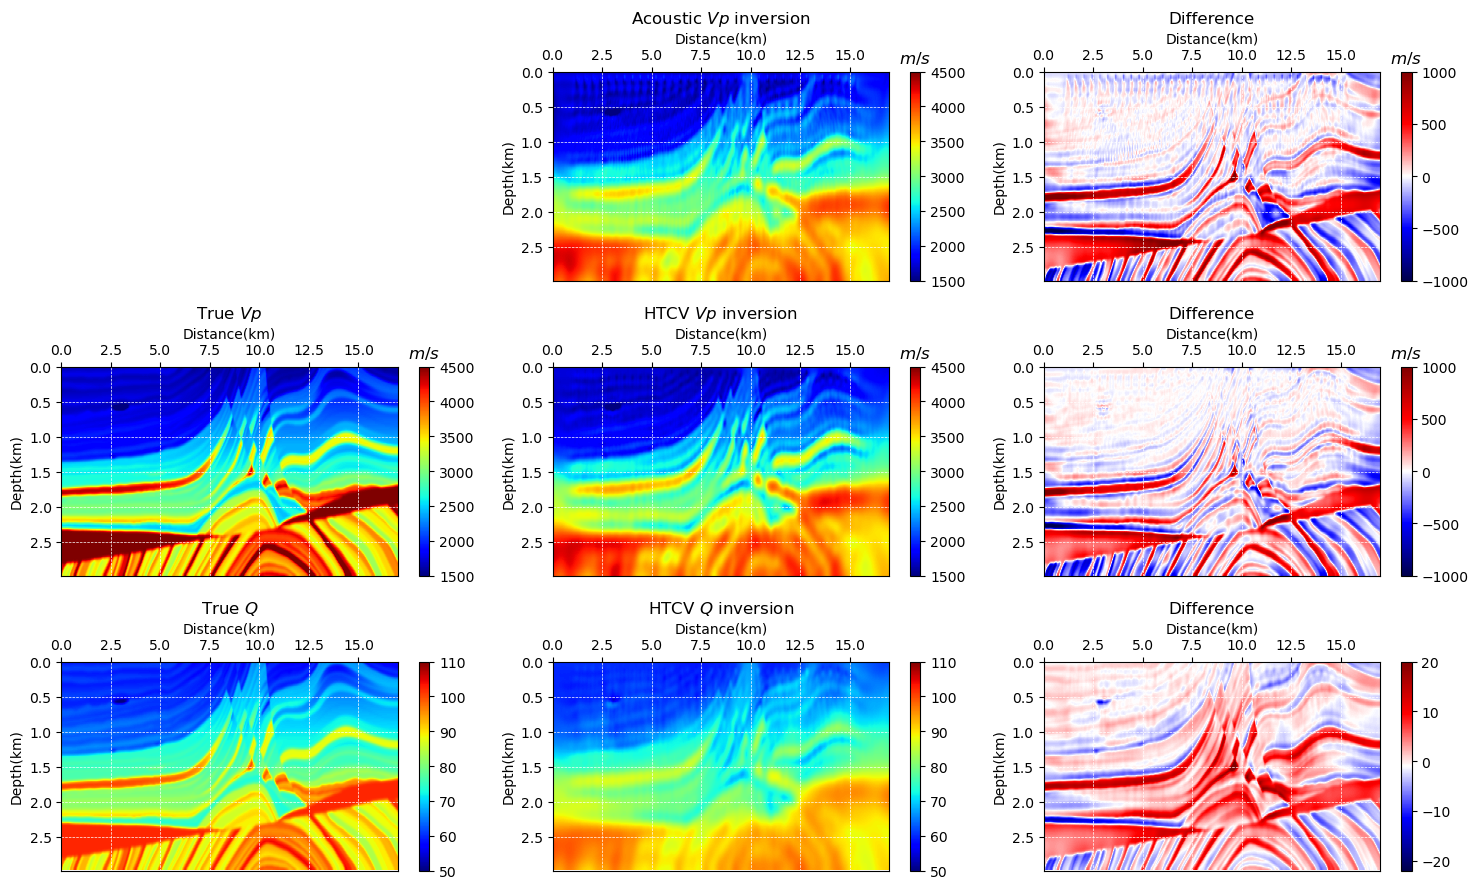

: 

In [ ]:
plt.figure(figsize=(15,9))
plt.subplot(3,3,4); imshow(true[:,:nx],clip=[1500,4500],colorbar_title=r'$m/s$',title=r'True $Vp$',label=['Distance(km)','Depth(km)']) 
plt.subplot(3,3,2); imshow(read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1500,4500],colorbar_title=r'$m/s$',title=r'Acoustic $Vp$ inversion',label=['Distance(km)','Depth(km)']) 
plt.subplot(3,3,3); imshow(true[:,:nx]-read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[-1000,1000],colorbar_title=r'$m/s$',cmap='seismic',title='Difference',label=['Distance(km)','Depth(km)'])
plt.subplot(3,3,5); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1500,4500],colorbar_title=r'$m/s$',title=r'HTCV $Vp$ inversion',label=['Distance(km)','Depth(km)'])
plt.subplot(3,3,6); imshow(true[:,:nx]-read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[-1000,1000],colorbar_title=r'$m/s$',cmap='seismic',title='Difference',label=['Distance(km)','Depth(km)'])
plt.subplot(3,3,7); imshow(true[:,2*nx:],clip=[50,110],colorbar_title=r'',title=r'True $Q$',label=['Distance(km)','Depth(km)']) 
plt.subplot(3,3,8); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:],clip=[50,110],colorbar_title=r'',title=r'HTCV $Q$ inversion',label=['Distance(km)','Depth(km)']) 
plt.subplot(3,3,9); imshow(true[:,2*nx:]-read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:],clip=[20,-20],colorbar_title=r'',cmap='seismic',title='Difference',label=['Distance(km)','Depth(km)'])
plt.tight_layout()
plt.savefig('./figures/FWI_result_comparison_with_true.svg',bbox_inches='tight',transparent=True)

: 